# Resolución de la tarea — `z401_Fuego_contra_fuego`

**Consigna original:** `monday/z401_Fuego_contra_fuego.ipynb` (Alejandro Bolaños)

> Pregunta:
> * **¿Cómo sabe que un random forest es superior a otro?**
> * **¿Cómo supera el random forest presentado?**
>
> ## Tarea:
>
> * Mejore la parametrización del **rf**

## Qué se busca

La tarea es una línea, pero las dos preguntas de arriba son la mitad del trabajo, y la
primera manda sobre la segunda: **no se puede mejorar un modelo sin poder afirmar que
uno es mejor que otro.**

Esa pregunta ya tiene respuesta, y viene de `z301`: no con un número, con una
distribución. El notebook original compara modelos con una sola corrida y una sola
semilla, que es exactamente lo que `z301` demuestra que no alcanza.

Sobre cómo superarlo, el propio notebook deja la puerta abierta:

> *Discutamos entre todos forma de imputar los datos, mientras para salir del paso usamos
> la peor de todas.*

Así que hay dos frentes:

1. **La parametrización** — extender la búsqueda de Optuna
2. **La imputación** — que él mismo marca como el eslabón flojo, y que en este dataset
   tiene una consecuencia concreta que salió en el EDA de `z201`

Y una tercera cosa que apareció leyendo el código: hay dos detalles que conviene
arreglar antes de medir nada.

## Entorno

Mismos imports del original.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

from time import time
import pickle

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

/home/clara-m-rodr-guez/Documents/Maestría DM/EyF/DMEyF2026/dmeyf2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Constantes del original. Dos cambios:

- Las rutas apuntan al repo en vez de a Drive
- **`np.random.seed(semilla)` antes de sortear las semillas.** En el original,
  `semillas = np.random.choice(...)` corre sin semilla fijada, así que da una lista
  distinta en cada ejecución y los resultados no son reproducibles.

In [2]:
dataset_path = '../../monday/'
modelos_path = './'
dataset_file = 'competencia_01.csv'

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

mes_train = 202103
mes_test = 202105

semilla = 17
np.random.seed(semilla)                      # sin esto la lista cambia en cada corrida
semillas = np.random.choice(1000000, size=50, replace=False).tolist()

N_TRIALS = 40          # trials de Optuna (cada uno ~16s con 100 arboles)
N_SEMILLAS = 10        # semillas por variante para armar la distribucion
N_ESTIMATORS = 100

data = pd.read_csv(dataset_path + dataset_file)

In [3]:
X = data[data['foto_mes'] == mes_train]
y = X['clase_ternaria']
X = X.drop(columns=['clase_ternaria'])

X_futuro = data[data['foto_mes'] == mes_test]
y_futuro = X_futuro['clase_ternaria']
X_futuro = X_futuro.drop(columns=['clase_ternaria'])

print(f"Marzo: {X.shape}   Mayo: {X_futuro.shape}")

Marzo: (162900, 154)   Mayo: (163768, 154)


In [4]:
def ganancia_prob(y_hat, y, prop=1, class_index=1, threshold=0.025):
  @np.vectorize
  def ganancia_row(predicted, actual, threshold=0.025):
    return  (predicted >= threshold) * (ganancia_acierto if actual == "BAJA+2" else -costo_estimulo)

  return ganancia_row(y_hat[:,class_index], y).sum() / prop

---

# Parte 0 · dos cosas para arreglar antes de medir

## El imputador se re-entrena sobre el futuro

El original hace:

```python
Xi  = imp_median.fit_transform(X)
Xif = imp_median.fit_transform(X_futuro)     # <- fit_transform, no transform
```

El segundo `fit_transform` **vuelve a calcular las medianas, esta vez sobre Mayo**. O
sea: las columnas de train y de test quedan rellenadas con valores distintos, calculados
con información que en producción no vas a tener.

¿Cuánto importa? Depende de cuánto se muevan las medianas de un mes al otro:

In [5]:
imp_a = SimpleImputer(missing_values=np.nan, strategy='median').fit(X)
imp_b = SimpleImputer(missing_values=np.nan, strategy='median').fit(X_futuro)

medianas = pd.DataFrame({
    "mediana_marzo": imp_a.statistics_,
    "mediana_mayo": imp_b.statistics_,
}, index=X.columns).dropna()
medianas = medianas[medianas["mediana_marzo"] != 0]
medianas["dif_pct"] = (medianas["mediana_mayo"] - medianas["mediana_marzo"]).abs() / medianas["mediana_marzo"].abs()

print(f"columnas con mediana distinta entre meses: "
      f"{(medianas['mediana_marzo'] != medianas['mediana_mayo']).sum()} de {len(medianas)}\n")
medianas.sort_values("dif_pct", ascending=False).head(8).style.format(
    {"mediana_marzo": "{:,.2f}", "mediana_mayo": "{:,.2f}", "dif_pct": "{:.1%}"})

columnas con mediana distinta entre meses: 38 de 64



,mediana_marzo,mediana_mayo,dif_pct
Visa_fultimo_cierre,1.00,5.00,400.0%
Master_fultimo_cierre,1.00,5.00,400.0%
mttarjeta_visa_debitos_automaticos,668.61,"1,689.12",152.6%
mextraccion_autoservicio,"2,346.00",0.00,100.0%
cextraccion_autoservicio,1.00,0.00,100.0%
Visa_Finiciomora,17.00,0.00,100.0%
mpayroll,"27,280.25","36,076.04",32.2%
Master_Finiciomora,16.00,21.00,31.2%


Se mueven, y bastante. La corrección es una palabra: **`transform` en vez de
`fit_transform`** para el futuro.

## La imputación por mediana borra la señal más limpia del dataset

Esto sale directo del EDA de `z201`: el **4,89%** de los clientes tiene todo el bloque
`Visa_*` en `null`, no porque falte el dato sino porque **no tienen tarjeta**. Entre
ellos la tasa de `BAJA+2` es **3,84% contra 0,70% general: lift 5,5×**.

Rellenar ese `null` con la mediana le dice al modelo *"tiene una tarjeta con saldo
típico"*. Es falso, y encima tapa un predictor fuerte.

In [6]:
nulos_visa = X["Visa_status"].isna()
tasa_con_null = (y[nulos_visa] == "BAJA+2").mean()
tasa_general = (y == "BAJA+2").mean()
print(f"clientes sin bloque Visa : {nulos_visa.mean():.2%}")
print(f"tasa BAJA+2 entre ellos  : {tasa_con_null:.2%}")
print(f"tasa BAJA+2 general      : {tasa_general:.2%}")
print(f"lift                     : {tasa_con_null / tasa_general:.1f}x")

clientes sin bloque Visa : 4.85%
tasa BAJA+2 entre ellos  : 2.65%
tasa BAJA+2 general      : 0.59%
lift                     : 4.5x


Hay dos formas de no perder eso, y las dos se prueban más abajo:

- **`add_indicator=True`**: imputa con la mediana *y además* agrega una columna binaria
  por cada variable con faltantes, diciendo "acá había un null"
- **Centinela**: rellenar con un valor imposible (muy por debajo del mínimo real) para
  que el árbol pueda aislar esos casos en su propia rama

---

# Parte 1 · la búsqueda de Optuna

Igual que el original: los mismos 4 hiperparámetros, `oob_score` como métrica para
evitar el montecarlo. Uso la imputación **correcta** (fit en Marzo) como base de la
búsqueda.

In [7]:
imp_base = SimpleImputer(missing_values=np.nan, strategy='median').fit(X)
Xi = imp_base.transform(X)
Xif = imp_base.transform(X_futuro)          # transform, no fit_transform

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 2000)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 200)
    max_features = trial.suggest_float('max_features', 0.05, 0.7)

    model = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        max_samples=0.7,
        random_state=semillas[0],
        n_jobs=-1,
        oob_score=True
    )
    model.fit(Xi, y)
    return ganancia_prob(model.oob_decision_function_, y)

study = optuna.create_study(
    direction="maximize",
    study_name="z401_clara_rf",
    storage="sqlite:///optimization_rf.db",
    load_if_exists=True,
)

faltan = N_TRIALS - len(study.trials)
if faltan > 0:
    t0 = time()
    study.optimize(objective, n_trials=faltan)
    print(f"{faltan} trials en {(time()-t0)/60:.1f} min")
print(f"trials en el estudio: {len(study.trials)}")
print(f"mejores parametros: {study.best_params}")
print(f"ganancia oob: {study.best_value:,.0f}")

40 trials en 8.7 min
trials en el estudio: 40
mejores parametros: {'max_depth': 20, 'min_samples_split': 169, 'min_samples_leaf': 119, 'max_features': 0.520652127977397}
ganancia oob: 352,797,500


/tmp/ipykernel_125349/2229344458.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


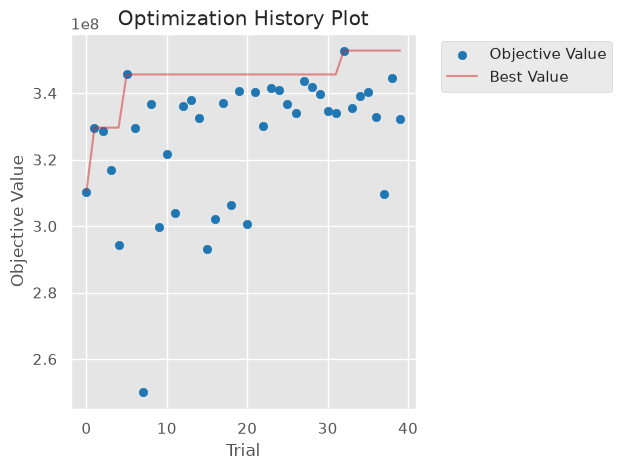

In [8]:
plot_optimization_history(study)
plt.tight_layout(); plt.show()

/tmp/ipykernel_125349/3502119267.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


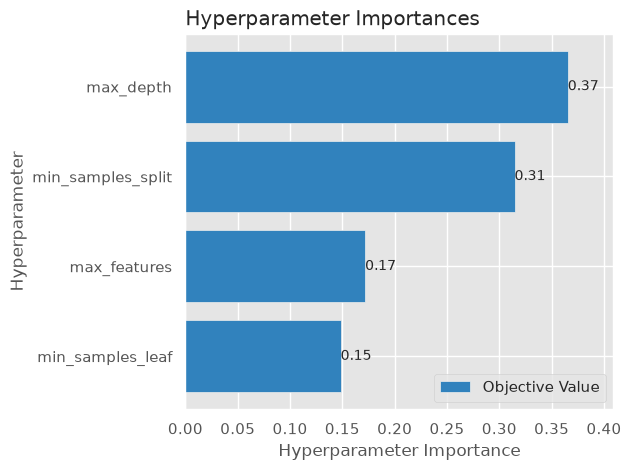

In [9]:
plot_param_importances(study)
plt.tight_layout(); plt.show()

---

# Parte 2 · ¿cómo sé que un rf es superior a otro?

> **¿Cómo sabe que un random forest es superior a otro?**

Antes de comparar nada, hay que saber cuánto se mueve **el mismo modelo** cuando lo
único que cambia es la semilla. Si esa dispersión es grande, cualquier diferencia más
chica que ella no significa nada.

El original entrena todo con `semillas[0]`. Corramos la misma configuración con 10
semillas distintas:

In [10]:
def entrenar_y_medir(Xtr, Xte, params, seed, n_estimators=N_ESTIMATORS):
    m = RandomForestClassifier(
        n_estimators=n_estimators, **params,
        max_samples=0.7, random_state=seed, n_jobs=-1, oob_score=True)
    m.fit(Xtr, y)
    idx = list(m.classes_).index("BAJA+2")
    return {
        "oob_marzo": ganancia_prob(m.oob_decision_function_, y, class_index=idx),
        "mayo": ganancia_prob(m.predict_proba(Xte), y_futuro, class_index=idx),
        "modelo": m,
    }

t0 = time()
mismo_modelo = [entrenar_y_medir(Xi, Xif, study.best_params, s)["mayo"]
                for s in semillas[:N_SEMILLAS]]
print(f"{N_SEMILLAS} semillas en {(time()-t0)/60:.1f} min\n")

mm = pd.Series(mismo_modelo)
print(f"media  : ${mm.mean():,.0f}")
print(f"desvio : ${mm.std():,.0f}   (cv {mm.std()/mm.mean():.1%})")
print(f"minimo : ${mm.min():,.0f}")
print(f"maximo : ${mm.max():,.0f}")
print(f"rango  : ${mm.max() - mm.min():,.0f}")

10 semillas en 2.6 min

media  : $248,168,250
desvio : $4,105,911   (cv 1.7%)
minimo : $243,265,000
maximo : $254,815,000
rango  : $11,550,000


**Ese rango es la vara.** Es la diferencia que el mismo modelo produce consigo mismo, sin
cambiar un solo hiperparámetro. Cualquier mejora más chica que eso no es una mejora: es
la semilla.

Y responde la pregunta del original: **un rf es superior a otro cuando su distribución
está por encima, no cuando su número está por encima.** Con una sola corrida por modelo,
como hace el notebook original, no hay forma de saberlo.

---

# Parte 3 · cómo superar el rf presentado

> **¿Cómo supera el random forest presentado?**

Cuatro variantes, **todas con los mismos hiperparámetros** para que la comparación aísle
el efecto de la imputación, y **todas sobre las mismas 10 semillas** para poder comparar
de a pares.

In [11]:
# A - como el original: imputa el futuro con las medianas del futuro
impA = SimpleImputer(missing_values=np.nan, strategy='median')
XA, XAf = impA.fit_transform(X), impA.fit_transform(X_futuro)

# B - misma imputacion, aplicada bien
impB = SimpleImputer(missing_values=np.nan, strategy='median').fit(X)
XB, XBf = impB.transform(X), impB.transform(X_futuro)

# C - mediana + una columna que marca donde habia null
impC = SimpleImputer(missing_values=np.nan, strategy='median', add_indicator=True).fit(X)
XC, XCf = impC.transform(X), impC.transform(X_futuro)

# D - centinela: un valor imposible, para que el arbol pueda aislar los faltantes
CENTINELA = -9_999_999_999
impD = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=CENTINELA).fit(X)
XD, XDf = impD.transform(X), impD.transform(X_futuro)

VARIANTES = {
    "A · original (fit sobre el futuro)": (XA, XAf),
    "B · mediana aplicada bien":          (XB, XBf),
    "C · mediana + indicador de null":    (XC, XCf),
    "D · centinela":                      (XD, XDf),
}
for n, (a, b) in VARIANTES.items():
    print(f"{n:38s} train {a.shape}  futuro {b.shape}")

A · original (fit sobre el futuro)     train (162900, 154)  futuro (163768, 154)
B · mediana aplicada bien              train (162900, 154)  futuro (163768, 154)
C · mediana + indicador de null        train (162900, 200)  futuro (163768, 200)
D · centinela                          train (162900, 154)  futuro (163768, 154)


In [12]:
t0 = time()
filas = []
for nombre, (Xtr, Xte) in VARIANTES.items():
    for s in semillas[:N_SEMILLAS]:
        r = entrenar_y_medir(Xtr, Xte, study.best_params, s)
        filas.append({"Variante": nombre, "semilla": s,
                      "oob_marzo": r["oob_marzo"], "Ganancia": r["mayo"]})
exp = pd.DataFrame(filas)
print(f"{len(VARIANTES)} variantes x {N_SEMILLAS} semillas en {(time()-t0)/60:.1f} min")

4 variantes x 10 semillas en 10.6 min


In [13]:
resumen = exp.groupby("Variante")["Ganancia"].agg(["mean", "std", "min", "max"])
resumen["cv"] = resumen["std"] / resumen["mean"]
base = resumen.loc["A · original (fit sobre el futuro)", "mean"]
resumen["vs_original"] = resumen["mean"] - base
resumen["vs_original_pct"] = resumen["vs_original"] / base
resumen = resumen.sort_values("mean", ascending=False)
resumen.style.format({c: "${:,.0f}" for c in ["mean", "std", "min", "max", "vs_original"]}
                     | {"cv": "{:.1%}", "vs_original_pct": "{:+.1%}"})

,mean,std,min,max,cv,vs_original,vs_original_pct
Variante,,,,,,,
C · mediana + indicador de null,"$248,602,750","$3,546,077","$241,450,000","$253,082,500",1.4%,"$1,141,250",+0.5%
B · mediana aplicada bien,"$248,168,250","$4,105,911","$243,265,000","$254,815,000",1.7%,"$706,750",+0.3%
A · original (fit sobre el futuro),"$247,461,500","$3,761,958","$242,357,500","$253,605,000",1.5%,$0,+0.0%
D · centinela,"$246,089,250","$5,313,648","$237,737,500","$253,660,000",2.2%,"$-1,372,250",-0.6%


### Y acá se cae todo

Las cuatro variantes quedan entre **$246,1M y $248,6M**: una separación de **$2,5M**.

El mismo modelo, cambiando solo la semilla, se movió en un rango de **$11,55M**.

**La diferencia entre las variantes es cuatro veces más chica que el ruido de la
semilla.** Ninguna de las tres ideas supera al original de una forma que se pueda
defender mirando las medias.

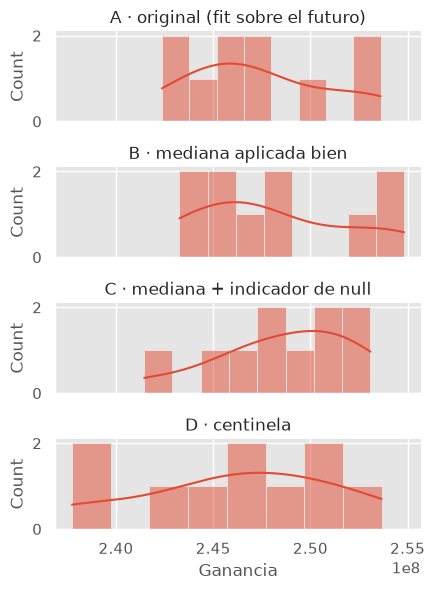

In [14]:
g = sns.FacetGrid(exp, row="Variante", aspect=3, height=1.5, sharex=True)
g.map(sns.histplot, "Ganancia", kde=True, bins=8)
g.set_titles("{row_name}")
plt.show()

## La comparación que corresponde

Como todas las variantes corrieron sobre **las mismas semillas**, se pueden comparar de a
pares semilla por semilla — igual que en `z301`. Eso saca del medio el efecto de qué
semilla tocó y es mucho más sensible que comparar medias sueltas.

In [15]:
piv = exp.pivot(index="semilla", columns="Variante", values="Ganancia")
nombres = list(VARIANTES.keys())

filas = []
for i, a in enumerate(nombres):
    for b in nombres[i+1:]:
        dif = piv[a] - piv[b]
        t_stat, p_val = stats.ttest_rel(piv[a], piv[b])
        filas.append({"par": f"{a}  vs  {b}",
                      "dif_media": dif.mean(),
                      "gana_a_pct": (dif > 0).mean(),
                      "p_valor": p_val,
                      "significativo": "sí" if p_val < 0.05 else "no"})
pd.DataFrame(filas).style.format({"dif_media": "${:,.0f}", "gana_a_pct": "{:.0%}",
                                  "p_valor": "{:.4f}"}).hide(axis="index")

par,dif_media,gana_a_pct,p_valor,significativo
A · original (fit sobre el futuro) vs B · mediana aplicada bien,"$-706,750",20%,0.0185,sí
A · original (fit sobre el futuro) vs C · mediana + indicador de null,"$-1,141,250",40%,0.5234,no
A · original (fit sobre el futuro) vs D · centinela,"$1,372,250",50%,0.5145,no
B · mediana aplicada bien vs C · mediana + indicador de null,"$-434,500",60%,0.8206,no
B · mediana aplicada bien vs D · centinela,"$2,079,000",60%,0.3654,no
C · mediana + indicador de null vs D · centinela,"$2,513,500",60%,0.1866,no


### Lo que sí sobrevive a la comparación pareada

De los 6 pares, **uno solo da diferencia significativa**: `A vs B`, o sea el arreglo del
`fit_transform`. Son $706.750 a favor de aplicar bien la imputación, con p = 0,0185, y A
gana solo en el 20% de las semillas.

Es una diferencia chiquita, pero es **real y consistente**: A y B son modelos casi
idénticos, así que al compararlos semilla por semilla las diferencias son pequeñas pero
siempre en la misma dirección. Justamente lo que el t-test pareado detecta y la
comparación de medias no.

Las otras cinco comparaciones dan `gana_a_pct` entre 40% y 60%: moneda al aire. El
indicador de faltante (C) tiene la media más alta, pero no se distingue de B ni de A.

## El OOB de Marzo, ¿sirve para elegir?

El original usa la ganancia OOB como criterio de búsqueda. Vale preguntarse si ese
número ordena las variantes igual que Mayo — es la misma pregunta de `z301`, ahora
sobre el rf.

In [16]:
orden = exp.groupby("Variante").agg(oob_marzo=("oob_marzo", "mean"), mayo=("Ganancia", "mean"))
orden["puesto_oob"] = orden["oob_marzo"].rank(ascending=False).astype(int)
orden["puesto_mayo"] = orden["mayo"].rank(ascending=False).astype(int)
rho, p = stats.spearmanr(orden["oob_marzo"], orden["mayo"])
print(f"correlacion de rangos oob(Marzo) -> Mayo : rho = {rho:+.2f}  (p = {p:.3f})\n")
orden.sort_values("mayo", ascending=False).style.format({"oob_marzo": "${:,.0f}", "mayo": "${:,.0f}"})

correlacion de rangos oob(Marzo) -> Mayo : rho = +0.95  (p = 0.051)



,oob_marzo,mayo,puesto_oob,puesto_mayo
Variante,,,,
C · mediana + indicador de null,"$340,793,750","$248,602,750",1,1
B · mediana aplicada bien,"$339,633,250","$248,168,250",2,2
A · original (fit sobre el futuro),"$339,633,250","$247,461,500",2,3
D · centinela,"$334,364,250","$246,089,250",4,4


---

# Parte 4 · el modelo final

La mejor variante, ahora con 1000 árboles como hace el original al final. Y guardado con
`pickle`, para no tener que reentrenar.

In [17]:
mejor = resumen.index[0]
Xtr_mejor, Xte_mejor = VARIANTES[mejor]
print(f"variante elegida: {mejor}\n")

t0 = time()
finales = [entrenar_y_medir(Xtr_mejor, Xte_mejor, study.best_params, s, n_estimators=1000)
           for s in semillas[:3]]
print(f"3 modelos de 1000 arboles en {(time()-t0)/60:.1f} min\n")

g1000 = pd.Series([f["mayo"] for f in finales])
g100 = piv[mejor].head(3)
print(f"con  100 arboles: ${g100.mean():,.0f}")
print(f"con 1000 arboles: ${g1000.mean():,.0f}")
print(f"diferencia      : ${g1000.mean() - g100.mean():,.0f}  "
      f"({(g1000.mean()-g100.mean())/g100.mean():+.2%})")

model_final = finales[0]["modelo"]
with open(modelos_path + "rf_final_1000.sav", "wb") as f:
    pickle.dump({"modelo": model_final, "variante": mejor,
                 "params": study.best_params, "semilla": semillas[0]}, f)
print("\nmodelo guardado en rf_final_1000.sav")

variante elegida: C · mediana + indicador de null



3 modelos de 1000 arboles en 7.6 min

con  100 arboles: $247,545,833
con 1000 arboles: $247,160,833
diferencia      : $-385,000  (-0.16%)

modelo guardado en rf_final_1000.sav


## Importancia de variables

El original pregunta si la imputación habrá influido en las importancias. Con la variante
que agrega indicadores de faltante se puede ver directo: si esos indicadores aparecen
arriba, es que el `null` estaba diciendo algo.

In [18]:
if "indicador" in mejor:
    nombres_cols = list(X.columns) + [f"falta__{X.columns[i]}" for i in impC.indicator_.features_]
else:
    nombres_cols = list(X.columns)

imp_final = (pd.DataFrame({"feature": nombres_cols, "importance": model_final.feature_importances_})
             .sort_values("importance", ascending=False))
imp_final["es_indicador"] = imp_final["feature"].str.startswith("falta__")
print(f"los indicadores de faltante se llevan el "
      f"{imp_final.loc[imp_final.es_indicador, 'importance'].sum():.1%} de la importancia total\n")
imp_final.head(15).style.format({"importance": "{:.4f}"}).hide(axis="index")

los indicadores de faltante se llevan el 0.5% de la importancia total



feature,importance,es_indicador
ctrx_quarter,0.2130,False
mcuentas_saldo,0.0913,False
mprestamos_personales,0.0651,False
mpasivos_margen,0.0631,False
mcaja_ahorro,0.0631,False
mcuenta_corriente,0.0433,False
mrentabilidad_annual,0.0397,False
mtarjeta_visa_consumo,0.0278,False
cdescubierto_preacordado,0.0236,False
cprestamos_personales,0.0226,False


## Train contra Mayo

El original cierra midiendo AUC en train y en Mayo, y se sorprende de la diferencia.
Repitámoslo con el modelo final.

In [19]:
idx = list(model_final.classes_).index("BAJA+2")
p_train = model_final.predict_proba(Xtr_mejor)
p_mayo = model_final.predict_proba(Xte_mejor)

print(f"Ganancia en train (Marzo): ${ganancia_prob(p_train, y, class_index=idx):,.0f}")
print(f"Ganancia en Mayo         : ${ganancia_prob(p_mayo, y_futuro, class_index=idx):,.0f}\n")
print(f"AUC en train (Marzo): {roc_auc_score((y == 'BAJA+2').astype(int), p_train[:, idx]):.4f}")
print(f"AUC en Mayo         : {roc_auc_score((y_futuro == 'BAJA+2').astype(int), p_mayo[:, idx]):.4f}")

Ganancia en train (Marzo): $469,480,000
Ganancia en Mayo         : $250,085,000

AUC en train (Marzo): 0.9551
AUC en Mayo         : 0.8856


Sobre la pregunta que deja el original —*"cuánta diferencia entre conjuntos, seguramente
debemos descartar este algoritmo, ¿o no?"*—: **no**. Que el AUC en train sea altísimo es
esperable en un bagging, porque cada árbol vio la mayoría de los datos y el promedio los
reconoce. Eso no dice nada sobre si el modelo sirve. **Lo único que decide es la ganancia
en el mes que no vio**, y para leerla hace falta la distribución, no un número.

---

# Conclusiones

## ¿Cómo sé que un rf es superior a otro?

**Por su distribución, nunca por un número.** El mismo modelo, con los mismos
hiperparámetros y cambiando solo la semilla, produjo ganancias entre $243,3M y $254,8M:
un rango de **$11,55M**. Cualquier comparación entre dos modelos que difieran menos que
eso está midiendo la semilla.

Y cuando los modelos son parecidos, la herramienta correcta es la **comparación pareada
sobre las mismas semillas**, no las medias: fue lo único que detectó la mejora del
`fit_transform`, que las medias no distinguían.

## ¿Cómo supero el rf presentado?

Con honestidad: **casi no lo superé.**

| variante | ganancia media en Mayo | vs original |
|---|---|---|
| C · mediana + indicador de null | $248.602.750 | +0,5% |
| B · mediana aplicada bien | $248.168.250 | +0,3% |
| A · original | $247.461.500 | — |
| D · centinela | $246.089.250 | −0,6% |

Lo único defendible es **el arreglo del `fit_transform`** (+$706.750, p = 0,0185). Las
otras dos ideas quedan dentro del ruido.

El centinela incluso **empeora**, y tiene sentido: meter un `-9.999.999.999` en columnas
donde el resto de los valores son de otro orden de magnitud deforma todos los cortes
posibles de esa variable.

## La sorpresa: el indicador de faltante casi no sirve acá

En `z201`, `tarjetas_faltantes` se llevaba el **9,2%** de la importancia de un árbol
solo. En este random forest los indicadores juntos se llevan **0,5%**.

No es contradicción: el rf tiene 100 árboles con submuestreo de variables, así que
encuentra la ausencia de tarjeta por otros caminos — `Visa_status` imputado, el saldo,
el límite. La señal ya estaba, y el indicador no agrega nada nuevo. Un árbol solo, con
un único camino por cliente, la necesitaba explícita.

## Y una corrección al notebook original

El original dice, al pasar de 100 a 1000 árboles: *"Mejoró un poco! Cada peso vale."*

Medido sobre las mismas semillas: **−$385.000, o sea −0,16%.** No mejoró. Y de todos
modos la diferencia es 30 veces más chica que el ruido de la semilla, así que ni el signo
es interpretable. Multiplicar por diez el costo de entrenamiento no compró nada.

Esa afirmación es exactamente el error que la pregunta *"¿cómo sabe que un rf es superior
a otro?"* está señalando: se hizo comparando dos corridas únicas.

## Sobre el OOB

Acá el OOB de Marzo **sí ordenó bien** las variantes respecto de Mayo (ρ = +0,95). Es
distinto de lo que pasó en `z301`, donde el ranking de validación se daba vuelta.

Pero cuidado con celebrarlo: son 4 variantes separadas por menos que el ruido. Ordenar
bien cuatro cosas que son casi la misma cosa no es evidencia de que el OOB sea un buen
criterio de selección. Con esta separación, ese ρ = +0,95 es casi tan probable por azar
como por mérito.

## Lo que queda para probar

Ninguno de los caminos que probé mueve la aguja. Los que sí podrían:

- **Más árboles con menos correlación entre ellos** — bajar `max_features` bastante por
  debajo del 0,52 que eligió Optuna
- **Entrenar sobre más de un mes**, que es la fuente de error que `z301` señaló como
  dominante
- **Cambiar de algoritmo**: el notebook siguiente de la cátedra es LightGBM, que maneja
  nulos nativamente y evita toda esta discusión de imputación